In this notebook, we use our knowledge of artists to build an animation. We continue using 311 data, but now look at timeseries

see also:

    https://matplotlib.org/devdocs/users/explain/animations/index.html


In [29]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from IPython.display import HTML
import numpy as np

In [3]:
geo311 = gpd.read_file("data/geolocated311.json")

In [4]:
geo311_agg = geo311.pivot_table(values='Additional Details', index='Borough', columns=['Problem Detail (formerly Descriptor)'], aggfunc='count').T
geo311_top5_complaints = geo311_agg.sum(axis=1).sort_values(ascending=False).index[:5]

In [5]:
geo311_top5 = geo311[geo311['Problem Detail (formerly Descriptor)'].isin(geo311_top5_complaints)]

In [6]:
cdict = dict(zip(geo311['Borough'].unique(), ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02']))

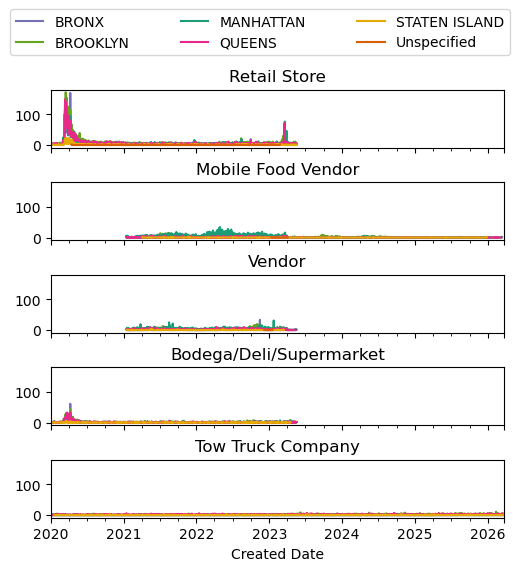

In [7]:
fig, axd = plt.subplot_mosaic([[g] for g in geo311_top5_complaints], sharex=True, sharey=True, figsize=(5,5), layout='compressed')

for name, gdfsub in geo311_top5.groupby(['Problem Detail (formerly Descriptor)']):
    axn = name[0]
    axd[axn].set_title(axn)
    for (b, gdfts) in gdfsub.groupby(['Borough']):
        gdfts.groupby(pd.Grouper(key='Created Date', freq='D'))['Problem Detail (formerly Descriptor)'].count().plot(ax=axd[axn], label=b[0], color=cdict[b[0]])
        
handles, labels = axd[axn].get_legend_handles_labels()
axd[axn].set(xlim=(geo311_top5['Created Date'].min(),geo311_top5['Created Date'].max()))
fig.legend(handles, labels, bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left', ncols=3, mode="expand", borderaxespad=0.)

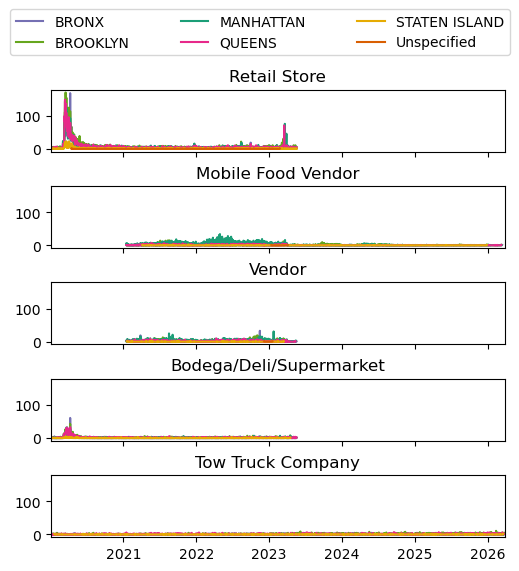

In [8]:
fig, axd = plt.subplot_mosaic([[g] for g in geo311_top5_complaints], sharex=True, sharey=True, figsize=(5,5), layout='compressed')

for name, gdfsub in geo311_top5.groupby(['Problem Detail (formerly Descriptor)']):
    axn = name[0]
    axd[axn].set_title(axn)
    for (b, gdfts) in gdfsub.groupby(['Borough']):
        ts = gdfts.groupby(pd.Grouper(key='Created Date', freq='D'))['Problem Detail (formerly Descriptor)'].count()
        l, = axd[axn].plot(ts.index, ts.values, label=b[0], color=cdict[b[0]])
handles, labels = axd[axn].get_legend_handles_labels()
axd[axn].set(xlim=(geo311_top5['Created Date'].min(),geo311_top5['Created Date'].max()))
fig.legend(handles, labels, bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left', ncols=3, mode="expand", borderaxespad=0.)


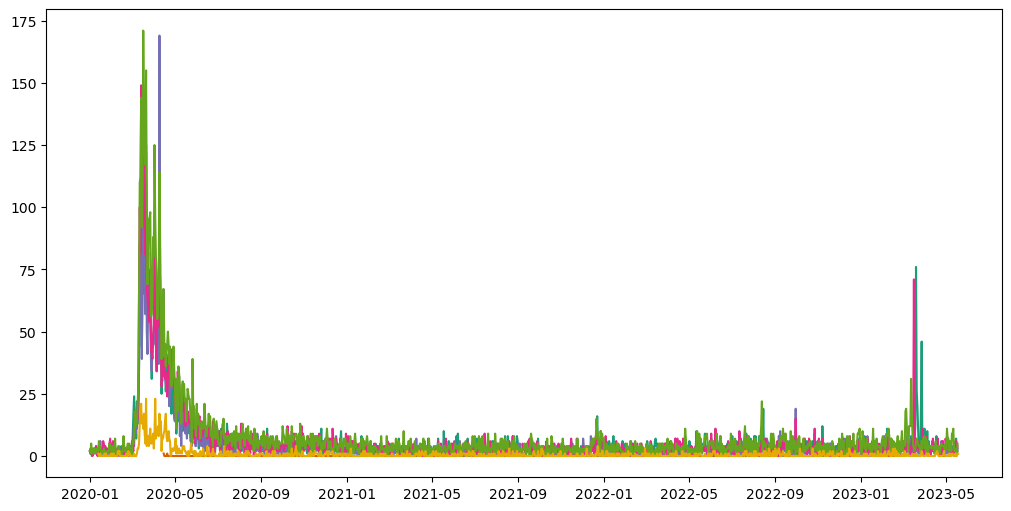

In [10]:
def get_days(date, borough, problem):
    subset = geo311_top5[(geo311_top5['Created Date'].dt.date <= date) & geo311_top5['Borough'].str.match(borough) & geo311_top5['Problem Detail (formerly Descriptor)'].str.match(problem)]
    return subset.groupby(pd.Grouper(key='Created Date', freq='D'))['Unique Key'].count()


g = geo311_top5_complaints[0]
boroughs = geo311_top5['Borough'].unique()

fig, axd = plt.subplot_mosaic([[g]], layout='compressed', figsize=(10,5))

date = geo311_top5['Created Date'].dt.date.max()
lines = dict()
for b in boroughs: 
    sdf = get_days(date, b, g)
    lines[b],  = axd[g].plot(sdf.index, sdf.values, label = b, color = cdict[b])



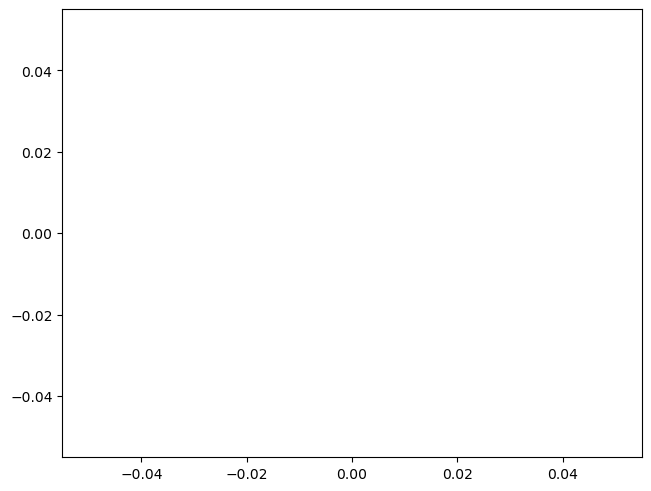

In [38]:
def get_days(date, borough, problem):
    return geo311_top5[(geo311_top5['Created Date'].dt.date <= date) & geo311_top5['Borough'].str.match(borough) & geo311_top5['Problem Detail (formerly Descriptor)'].str.match(problem)]['Unique Key'].count()


g = geo311_top5_complaints[0]
fig, axd = plt.subplot_mosaic([[g]], layout='compressed')

boroughs = geo311_top5['Borough'].unique()

dates = geo311_top5['Created Date'].dt.date.sort_values().unique()

lines = dict()

for b in boroughs: 
    lines[b],  = axd[g].plot([], [], label = b, color = cdict[b], ls='-', lw='2')


def update(i):
    date = dates[i]
    sdf = get_days(date, b, g)
    if np.isscalar(sdf):
        lines[b].set_data([date], [sdf])
    else:
        lines[b].set_data(sdf.index, sdf.values)
    return [lines[b] for b in boroughs]

ani = animation.FuncAnimation(fig, update, frames = len(dates), interval=300, blit=True)

In [39]:
ani.save("test.mp4")